In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import math
import torch

from mt_DIDC_config import LABEL2LABEL, PROPERTY_KEY, NEW_LABELS

from tx_GAN_train import CustomDatasetTexturizer

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  

%load_ext autoreload
%autoreload 2


In [2]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Selected device: {device}")
print(f'Num available GPUs: ', torch.cuda.device_count())


p = torch.cuda.get_device_properties()
print(f"Device: {p.name} (Memory: {p.total_memory / 1e9:.2f} GB)")

Selected device: cuda
Num available GPUs:  1
Device: NVIDIA TITAN RTX (Memory: 25.19 GB)


## Original dataset

In [ ]:
DATA_DIR = "./DIDC_multiclass_coro_v2_prep_2"
prop_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('props.npy')])
mask_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('mask.npy')])
print(len(prop_files),len(mask_files))
n_pats = 5
pat_idxs = np.random.choice(len(prop_files), size=n_pats, replace=False)
pat_idxs.sort()
print(pat_idxs)

458 458


load the patients

In [6]:
props_vect = np.load(os.path.join(DATA_DIR, prop_files[pat_idxs[0]]))
mask_vect = np.load(os.path.join(DATA_DIR, mask_files[pat_idxs[0]]))

for idx in pat_idxs[1:]:
    print(f"Loading patient index: {idx}")
    props = np.load(os.path.join(DATA_DIR, prop_files[idx]))
    mask = np.load(os.path.join(DATA_DIR, mask_files[idx]))
    props_vect = np.concatenate([props_vect, props], axis=0) 
    mask_vect = np.concatenate([mask_vect, mask], axis=0)

props_vect.shape, mask_vect.shape

Loading patient index: 235
Loading patient index: 258
Loading patient index: 321
Loading patient index: 436


((1478, 3, 384, 384), (1478, 384, 384))

In [ ]:
target_tissues = list(PROPERTY_KEY.keys())
num_tissues = len(target_tissues)

mapping_array = np.zeros(len(NEW_LABELS), dtype=np.int32)

for old_idx, old_label in enumerate(NEW_LABELS):
    mapped_tissue_name = LABEL2LABEL[old_label]
    new_idx = target_tissues.index(mapped_tissue_name)
    mapping_array[old_idx] = new_idx


remapped_mask = mapping_array[mask_vect] 

class_indices = np.arange(num_tissues)[:, None, None, None]  # (15, 1, 1, 1)
vol_mask_onehot = remapped_mask[None, ...] == class_indices
vol_mask_onehot.shape


In [9]:
props_perm =  np.permute_dims(props_vect, (1, 0, 2, 3))
dist = []
for i in range(vol_mask_onehot.shape[0]):
    class_mask = vol_mask_onehot[i] 
    class_props = props_perm[:, class_mask] 
    dist.append(class_props) 
    print(class_props.shape)


(3, 6514839)
(3, 7006507)
(3, 33939915)
(3, 20136413)
(3, 2107437)
(3, 11326585)
(3, 24089335)
(3, 424225)
(3, 1250958)
(3, 1362336)
(3, 99059)
(3, 4163227)
(3, 7754671)
(3, 96950599)
(3, 813862)


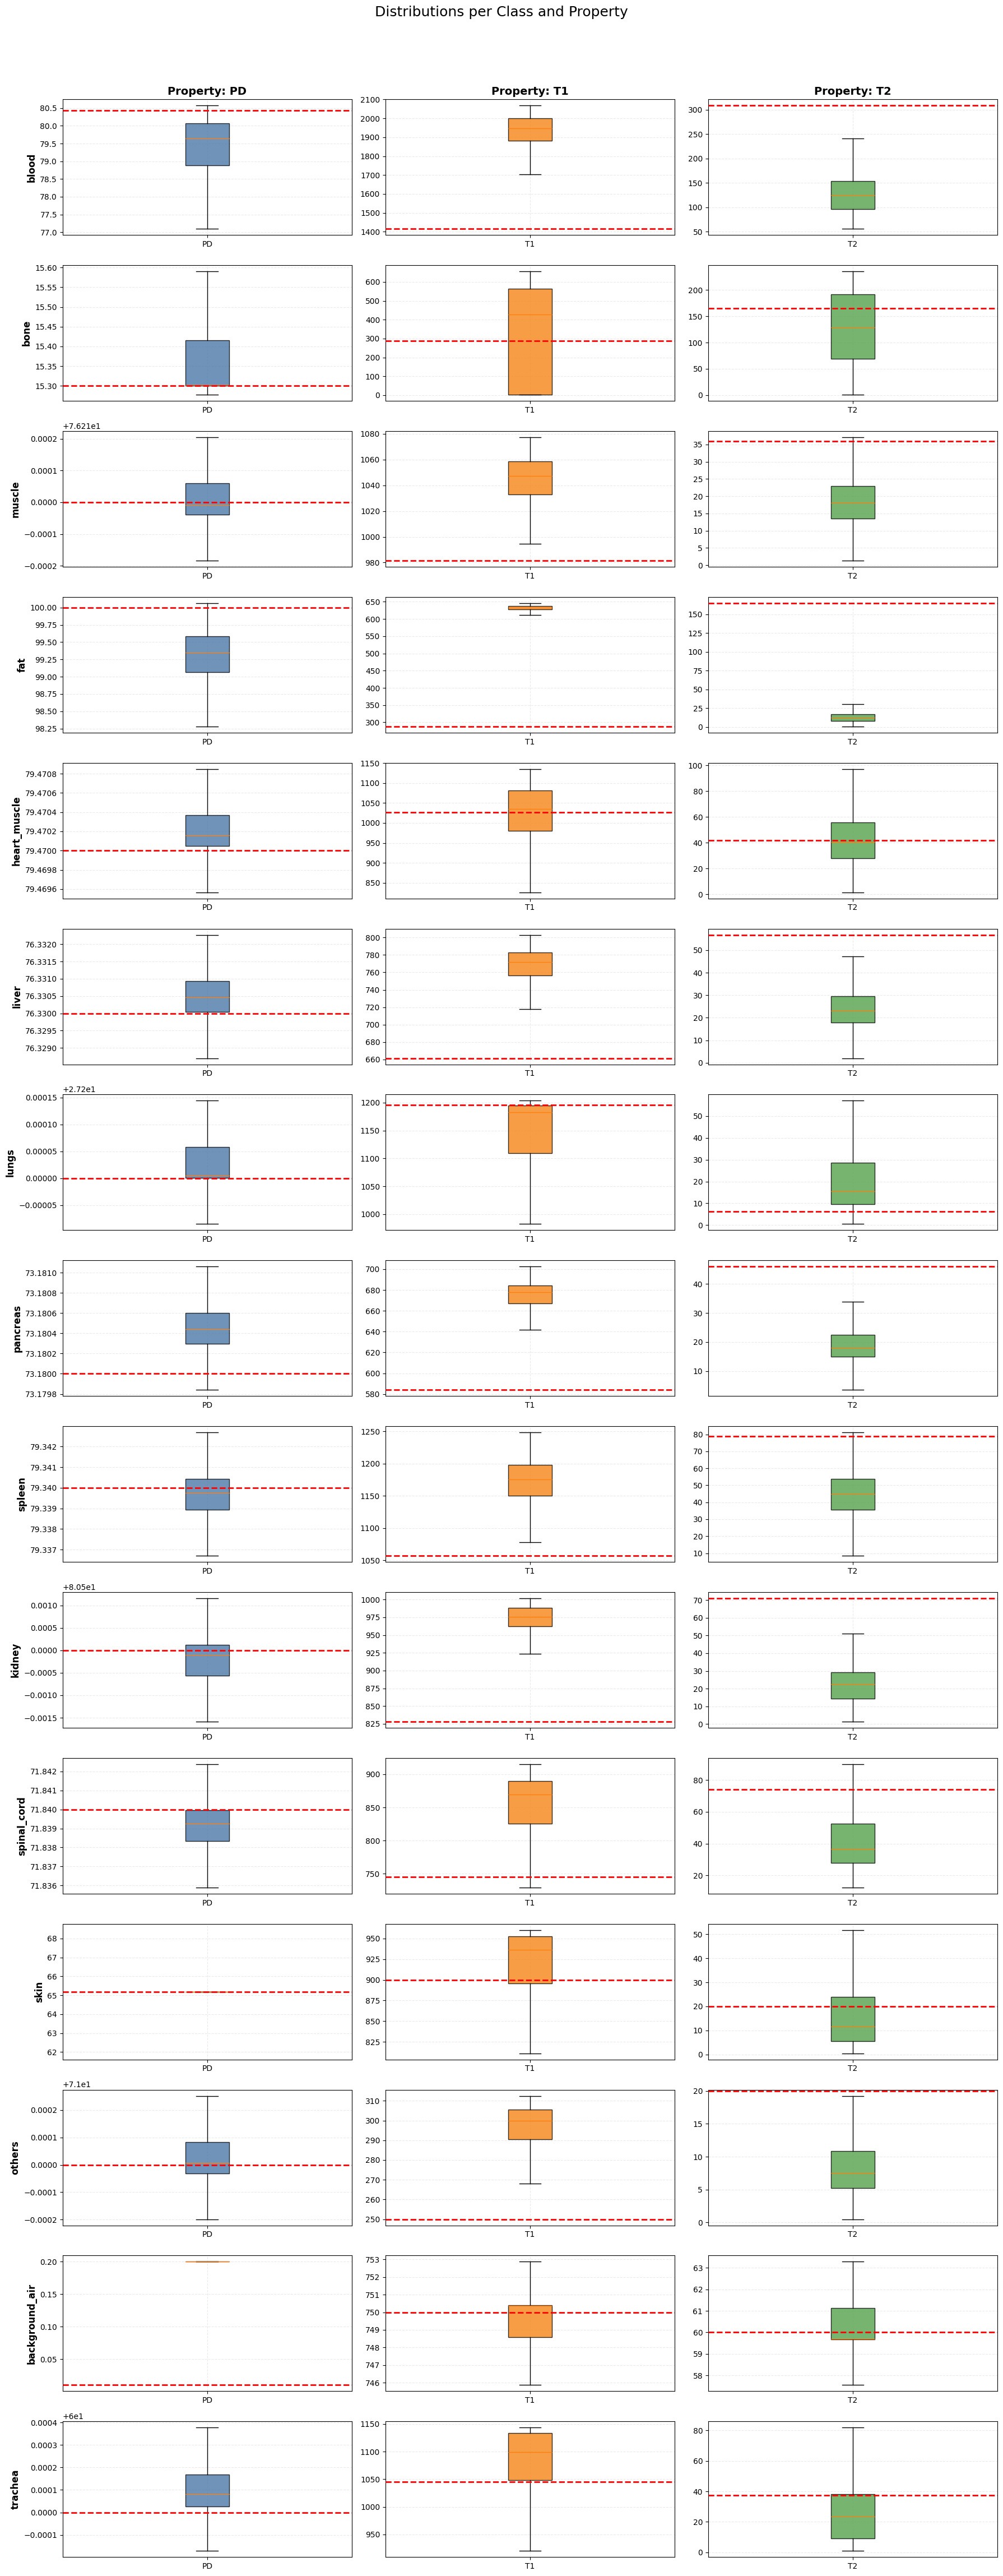

In [15]:
prop_names = ['PD', 'T1', 'T2']
n_classes = len(dist)
n_cols = 3  # PD, T1, T2
n_rows = n_classes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))

default_values = np.array(list(PROPERTY_KEY.values()))


max_points = 100000
colors = ["#4C78A8", "#F58518", "#54A24B"]

for i in range(n_classes):
    class_props = dist[i]
    class_label = list(PROPERTY_KEY.keys())[i]
    
    for j in range(n_cols):
        ax = axes[i, j]
        
        values = class_props[j]
        values = values[np.isfinite(values)]
        
        if values.size > max_points:
            idx = np.random.choice(values.size, size=max_points, replace=False)
            values = values[idx]

        if values.size == 0:
            values = np.array([np.nan], dtype=np.float32)
        
        bp = ax.boxplot([values], tick_labels=[prop_names[j]], showfliers=False, patch_artist=True)
        
        for box in bp["boxes"]:
            box.set_facecolor(colors[j])
            box.set_alpha(0.8)
        
        ax.axhline(y=default_values[i,j], color='red', linestyle='--', linewidth=2, zorder=3)

        ax.grid(alpha=0.25, linestyle="--")
    
        if j == 0:
            ax.set_ylabel(class_label, fontsize=12, fontweight='bold')
            
        if i == 0:
            ax.set_title(f"Property: {prop_names[j]}", fontsize=14, fontweight='bold')

fig.suptitle("Distributions per Class and Property", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## New dataset
reg weight from 0.001 -> 0.01. Stronger regularization

In [ ]:
DATA_DIR = 'DIDC_multiclass_coro_v2_prep_3'

prop_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('props.npy')])
mask_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('mask.npy')])
print(len(prop_files),len(mask_files))
n_pats = 5
pat_idxs = np.random.choice(len(prop_files), size=n_pats, replace=False)
pat_idxs.sort()
print(pat_idxs)

patient loading

In [ ]:
props_vect = np.load(os.path.join(DATA_DIR, prop_files[pat_idxs[0]]))
mask_vect = np.load(os.path.join(DATA_DIR, mask_files[pat_idxs[0]]))

for idx in pat_idxs[1:]:
    print(f"Loading patient index: {idx}")
    props = np.load(os.path.join(DATA_DIR, prop_files[idx]))
    mask = np.load(os.path.join(DATA_DIR, mask_files[idx]))
    props_vect = np.concatenate([props_vect, props], axis=0) 
    mask_vect = np.concatenate([mask_vect, mask], axis=0)

props_vect.shape, mask_vect.shape

label mapping

In [ ]:
target_tissues = list(PROPERTY_KEY.keys())
num_tissues = len(target_tissues)

mapping_array = np.zeros(len(NEW_LABELS), dtype=np.int32)

for old_idx, old_label in enumerate(NEW_LABELS):
    mapped_tissue_name = LABEL2LABEL[old_label]
    new_idx = target_tissues.index(mapped_tissue_name)
    mapping_array[old_idx] = new_idx


remapped_mask = mapping_array[mask_vect] 

class_indices = np.arange(num_tissues)[:, None, None, None]  # (15, 1, 1, 1)
vol_mask_onehot = remapped_mask[None, ...] == class_indices
vol_mask_onehot.shape

extracting distributions

In [ ]:
props_perm =  np.permute_dims(props_vect, (1, 0, 2, 3))
dist = []
for i in range(vol_mask_onehot.shape[0]):
    class_mask = vol_mask_onehot[i] 
    class_props = props_perm[:, class_mask] 
    dist.append(class_props) 
    print(class_props.shape)


box plots

In [ ]:
prop_names = ['PD', 'T1', 'T2']
n_classes = len(dist)
n_cols = 3  # PD, T1, T2
n_rows = n_classes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))

default_values = np.array(list(PROPERTY_KEY.values()))


max_points = 100000
colors = ["#4C78A8", "#F58518", "#54A24B"]

for i in range(n_classes):
    class_props = dist[i]
    class_label = list(PROPERTY_KEY.keys())[i]
    
    for j in range(n_cols):
        ax = axes[i, j]
        
        values = class_props[j]
        values = values[np.isfinite(values)]
        
        if values.size > max_points:
            idx = np.random.choice(values.size, size=max_points, replace=False)
            values = values[idx]

        if values.size == 0:
            values = np.array([np.nan], dtype=np.float32)
        
        bp = ax.boxplot([values], tick_labels=[prop_names[j]], showfliers=False, patch_artist=True)
        
        for box in bp["boxes"]:
            box.set_facecolor(colors[j])
            box.set_alpha(0.8)
        
        ax.axhline(y=default_values[i,j], color='red', linestyle='--', linewidth=2, zorder=3)

        ax.grid(alpha=0.25, linestyle="--")
    
        if j == 0:
            ax.set_ylabel(class_label, fontsize=12, fontweight='bold')
            
        if i == 0:
            ax.set_title(f"Property: {prop_names[j]}", fontsize=14, fontweight='bold')

fig.suptitle("Distributions per Class and Property", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

fai grafico che compara i diversi box plot dei diversi dataset